<a href="https://colab.research.google.com/github/onlyforstudy7770-cpu/DeepFake-voice-detection-project/blob/main/logistic_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# This file contains processing of data and logistic regression model
#this processed data  is used in other models  
This module establishes the foundational data pipeline for the deepfake detection system. It performs feature extraction and preprocessing on the raw audio dataset to create a standardized feature set. A Logistic Regression model is then trained on this processed data to serve as a high-recall baseline. Finally, the processed data is serialized and exported, ensuring consistent inputs for subsequent models (such as Random Forest and CNNs) to facilitate fair performance comparison

In [ ]:
import kagglehub
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
import os


downloading the data


In [ ]:
path = kagglehub.dataset_download("awsaf49/asvpoof-2019-dataset")


100%|██████████| 23.6G/23.6G [04:25<00:00, 95.3MB/s]

Extracting files...


In [ ]:
path = "/root/.cache/kagglehub/datasets/awsaf49/asvpoof-2019-dataset/versions/1"

In [ ]:

print("Path to dataset files:", path)

Path to dataset files: /root/.cache/kagglehub/datasets/awsaf49/asvpoof-2019-dataset/versions/1


To get the duration of the longest file, I use 0.01 as the least count.

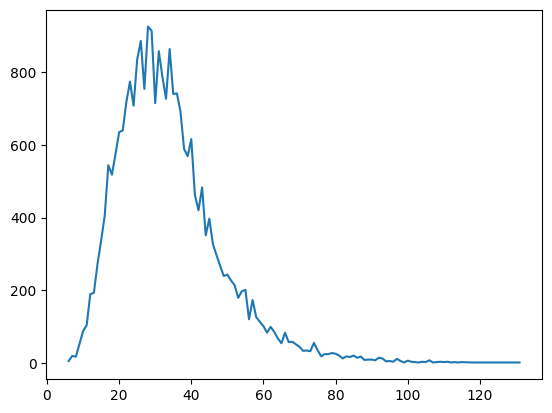

2.8 - 926


In [ ]:
file_name = os.listdir(path+"/LA/LA/ASVspoof2019_LA_train/flac")

dc ={}
for file in file_name:
  y = librosa.get_duration( path = path +"/LA/LA/ASVspoof2019_LA_train/flac/" + file)
  y = int ( y*10)
  if (y not in dc):
    dc[y] = 1
  else:
    dc[y] += 1


sorted_data = sorted(dc.items())
x, y = zip(*sorted_data)
plt.plot(x, y)
plt.show()

max = 0
l = 0

for i in range ( 0 , len(x)):
  if y[i] > max :
    max = y[i]
    l = x[i]
print ( l/10 , "-" , max)



making csv file of protocals and audio file

filename = file.flac                                                        
system_id == A0 , A1 , A2 etc                           
target == 0 (real) , 1 (sfooped)

In [ ]:
import pandas as pd

file = ("train.trn" , "eval.trl" )
for res in file:

  data_dec = {"filename" : [],
        "system_id":[],
        "target" : []}

  with open ( path+f"/LA/LA/ASVspoof2019_LA_cm_protocols/ASVspoof2019.LA.cm.{res}.txt" , 'r') as train:
    for line in train:

      data = line.strip().split()

      if (data[4] == "bonafide"):
          data_dec["filename"].append(data[1])
          data_dec["system_id"].append('-')
          data_dec["target"].append(0)

      else:

          data_dec["filename"].append(data[1])
          data_dec["target"].append(1)
          data_dec["system_id"].append(data[3])

  df = pd.DataFrame(data_dec)
  df.to_csv(f"/content/drive/MyDrive/ASVsfoop_data/{res.replace(".trl" , "").replace(".trn" , "")}.csv" , index = False)



Converting audio files into MFCCs and Log-Mel spectrograms.

In [ ]:

audio_sample_size = 4

fil = ("train" , "eval" )

for fi in fil:
  df = pd.read_csv(f"/content/drive/MyDrive/ASVsfoop_data/{fi}.csv")

  target_map = dict(zip(df["filename"], df["target"]))

  i = 0
  x = 0
  file_name = os.listdir(path+f"/LA/LA/ASVspoof2019_LA_{fi}/flac")

  os.makedirs(f"/content/drive/MyDrive/ASVsfoop_data/{fi}_mfcc" , exist_ok = True)
  os.makedirs(f"/content/drive/MyDrive/ASVsfoop_data/{fi}_s_db" , exist_ok = True)

  for file in file_name:

    csv_name = file.replace(".flac" , "")
    if (target_map.get(csv_name) is None):
      x+=1
      continue
    y , src =  librosa.load(path+f"/LA/LA/ASVspoof2019_LA_{fi}/flac/"+ file , sr = 16000)
    temp = int(audio_sample_size * src)


    if ( len(y) > temp):
      y = y[0:temp]
    elif ( len(y) <temp):
      y = np.pad(y , (0 ,temp-len(y)) , mode= 'constant')

    mfcc = librosa.feature.mfcc( y = y , sr = src , n_mfcc= 40)
    S = librosa.feature.melspectrogram(y = y, sr = src, n_mels = 128, fmax=8000)
    S_dB = librosa.power_to_db(S, ref=np.max)

    np.save(f"/content/drive/MyDrive/ASVsfoop_data/{fi}_mfcc/{file}" , mfcc)
    np.save(f"/content/drive/MyDrive/ASVsfoop_data/{fi}_s_db/{file}" , S_dB)

    i +=1
    if ( ( i / 100) % 1 == 0):
      print("\r" ,i ,"/",len(file_name), f"file_rejected  in {file} = {x}",end ="")
  print()

 25300 / 25380 file_rejected  in LA_T_6814023.flac = 0
 71200 / 71933 file_rejected  in LA_E_9705583.flac = 694


# LOGISTIC REGRESSION

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
import os


loading traning data

In [ ]:
X_train = []
y_train = []

res = ("train" , "eval" , "dev")

df = pd.read_csv("/content/drive/MyDrive/ASVsfoop_data/train.csv")

target_map = dict(zip(df["filename"], df["target"]))

folder_path = "/content/drive/MyDrive/ASVsfoop_data/train_mfcc"
folder = os.listdir(folder_path)

i = 0
for file in folder:
  csv_filename = file.replace(".flac.npy" , "")

  data = np.load(os.path.join(folder_path, file)).ravel()
  X_train.append(data)
  y_train.append(int(target_map[csv_filename]))
  i+= 1
  if ( ((i / len(folder) ) * 100) % 1 == 0):
    print("\r", i , "/" , len(folder) , end ="")


lol
 25380 / 25380

This code performs Dimensionality Reduction. It shrinks the number of features in  dataset while trying to keep 99% of the original information intact.

the 5040 input parameeters is compraced intp 1231 datapoints

In [ ]:
from sklearn.decomposition import PCA

print (len(X_train[0]))
pca = PCA(n_components=0.99)
X_train= pca.fit_transform(X_train)
print(len(X_train[0]))

5040
1231


In [ ]:

X_test = []
y_test = []

res = ("train" , "eval" , "dev")


df = pd.read_csv("/content/drive/MyDrive/ASVsfoop_data/eval.csv")

target_map = dict(zip(df["filename"], df["target"]))

folder_path = "/content/drive/MyDrive/ASVsfoop_data/eval_mfcc"
folder = os.listdir(folder_path)

for file in folder:
  csv_filename = file.replace(".flac.npy" , "")
  if (target_map.get(csv_filename) is None):
    continue

  data = np.load(os.path.join(folder_path, file)).ravel()
  X_test.append(data)
  y_test.append(int(target_map[csv_filename]))


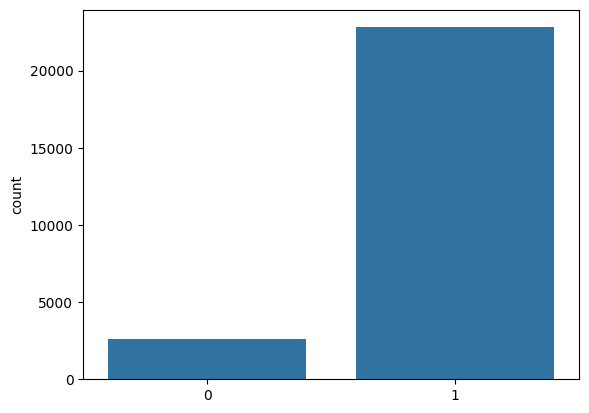

In [ ]:
#number of fake and real in training dataset

sns.countplot(x = y_train)

plt.show()

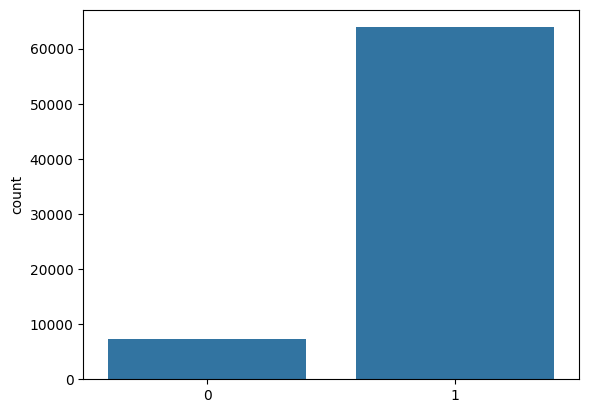

In [ ]:
#number of fake and real in testing dataset
sns.countplot(x = y_test)
plt.show()

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

In [ ]:
pipeline = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000 , class_weight='balanced'))
pipeline.fit(X_test , y_test)

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('logisticregression',
                 LogisticRegression(class_weight='balanced', max_iter=1000))])

In [ ]:
from sklearn.metrics import mean_squared_error , mean_absolute_error , r2_score
y_pred = pipeline.predict(X_train)

In [ ]:
from sklearn.metrics import  confusion_matrix , classification_report
print (confusion_matrix(y_train , y_pred))

[[ 1898   682]
 [ 1927 20873]]


In [ ]:
print(classification_report(y_train , y_pred))

              precision    recall  f1-score   support

           0       0.50      0.74      0.59      2580
           1       0.97      0.92      0.94     22800

    accuracy                           0.90     25380
   macro avg       0.73      0.83      0.77     25380
weighted avg       0.92      0.90      0.91     25380



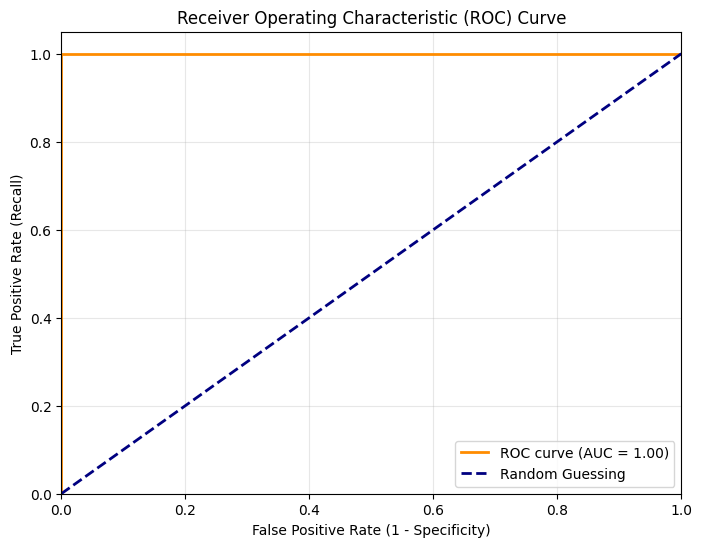

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

y_pred_proba = pipeline.predict_proba(X_test)[:, 1]

# Calculate ROC curve metrics
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

# Plot the ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Guessing')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Recall)')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

equation used in logistic regression9 => y = (1/(1 + e^-1*(mX + b)))